# 05_engien_based_validation
## Goals
- Create engine-based training and validation sets
- Train the LSTM RUL prediction model
- Monitor training and validation performance
- Evaluate the model on the FD001 test set
- Compute RMSE, MAE, R², and NASA score
- Analyze prediction behavior across different RUL ranges

In [1]:
import sys
from pathlib import Path
import random

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils.sequence import create_test_sequences

In [2]:
SEED = 9

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
EXPERIMENT_NAME = "lstm_engine_val_seq30_cap125"

SEQ_LENGTH = 30
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 0.001

print("Experiment:", EXPERIMENT_NAME)

Experiment: lstm_engine_val_seq30_cap125


In [5]:
df_train = pd.read_csv(PROCESSED_DIR / "train_fd001_processed.csv")
df_test = pd.read_csv(PROCESSED_DIR / "test_fd001_processed.csv")
df_rul_test = pd.read_csv(PROCESSED_DIR / "rul_fd001_test.csv")

feature_cols = pd.read_csv(PROCESSED_DIR / "fd001_feature_cols.csv", header=None)[0].tolist()

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("Features:", len(feature_cols))

Train shape: (20631, 27)
Test shape: (13096, 26)
Features: 15


In [6]:
def create_sequences_for_units(df, feature_cols, seq_length, units):
    X, y = [], []

    for unit in units:
        unit_df = df[df["unit"] == unit].sort_values("cycle")

        for i in range(len(unit_df) - seq_length + 1):
            seq_x = unit_df.iloc[i:i + seq_length][feature_cols].values
            seq_y = unit_df.iloc[i + seq_length - 1]["RUL"]

            X.append(seq_x)
            y.append(seq_y)

    return np.array(X), np.array(y)

In [7]:
all_units = df_train["unit"].unique()
np.random.shuffle(all_units)

n_train_units = int(0.8 * len(all_units))

train_units = all_units[:n_train_units]
val_units = all_units[n_train_units:]

print("Train engines:", len(train_units))
print("Validation engines:", len(val_units))
print("Train units:", train_units[:10])
print("Validation units:", val_units[:10])

Train engines: 80
Validation engines: 20
Train units: [76 43 47 69  4 40 24 21 71 74]
Validation units: [  2  86  19  13  63  98  75 100  61   1]


In [8]:
X_train, y_train = create_sequences_for_units(
    df_train,
    feature_cols,
    SEQ_LENGTH,
    train_units
)

X_val, y_val = create_sequences_for_units(
    df_train,
    feature_cols,
    SEQ_LENGTH,
    val_units
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (14454, 30, 15)
y_train: (14454,)
X_val: (3277, 30, 15)
y_val: (3277,)


In [9]:
X_test = create_test_sequences(df_test, feature_cols, SEQ_LENGTH)
y_test = df_rul_test["RUL"].values

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (100, 30, 15)
y_test: (100,)


In [10]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [11]:
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 226
Validation batches: 52
Test batches: 2


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [13]:
class LSTMRULModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)
        last_hidden = hidden[-1]
        return self.regressor(last_hidden)

In [14]:
class GRURULModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        gru_out, hidden = self.gru(x)
        last_hidden = hidden[-1]
        return self.regressor(last_hidden)

In [15]:
input_size = X_train.shape[2]

model = LSTMRULModel(
    input_size=input_size,
    hidden_size=64,
    num_layers=1,
    dropout=0.0
).to(device)

#GRU Model alternative
# model = GRURULModel(
#     input_size=input_size,
#     hidden_size=64,
#     num_layers=1,
#     dropout=0.0
# ).to(device)

class AsymmetricLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        error = y_pred - y_true

        loss = torch.where(
            error < 0,
            torch.exp(-error / 13) - 1,
            torch.exp(error / 10) - 1
        )

        return torch.mean(loss)
    
criterion = nn.MSELoss() #AsymetricLoss() alternative
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

LSTMRULModel(
  (lstm): LSTM(15, 64, batch_first=True)
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            all_preds.append(predictions.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    all_preds = np.vstack(all_preds).flatten()
    all_targets = np.vstack(all_targets).flatten()

    return epoch_loss, all_preds, all_targets

In [17]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_path = MODELS_DIR / f"{EXPERIMENT_NAME}.pt"

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

print("Best validation loss:", best_val_loss)
print("Best model saved to:", best_model_path)

Epoch 01/30 | Train Loss: 4380.9265 | Val Loss: 1719.5966
Epoch 02/30 | Train Loss: 1752.5581 | Val Loss: 1728.0955
Epoch 03/30 | Train Loss: 1751.6384 | Val Loss: 1735.7095
Epoch 04/30 | Train Loss: 1737.1798 | Val Loss: 1648.5991
Epoch 05/30 | Train Loss: 875.5251 | Val Loss: 319.0758
Epoch 06/30 | Train Loss: 237.0374 | Val Loss: 236.0649
Epoch 07/30 | Train Loss: 198.7715 | Val Loss: 241.0734
Epoch 08/30 | Train Loss: 188.9994 | Val Loss: 216.5276
Epoch 09/30 | Train Loss: 182.9714 | Val Loss: 235.1863
Epoch 10/30 | Train Loss: 182.9861 | Val Loss: 221.8051
Epoch 11/30 | Train Loss: 180.8552 | Val Loss: 209.2752
Epoch 12/30 | Train Loss: 177.8334 | Val Loss: 205.8526
Epoch 13/30 | Train Loss: 171.6087 | Val Loss: 220.4999
Epoch 14/30 | Train Loss: 176.1582 | Val Loss: 259.6867
Epoch 15/30 | Train Loss: 172.6116 | Val Loss: 196.4245
Epoch 16/30 | Train Loss: 170.2038 | Val Loss: 200.9775
Epoch 17/30 | Train Loss: 172.3178 | Val Loss: 231.7413
Epoch 18/30 | Train Loss: 165.8536 | Val

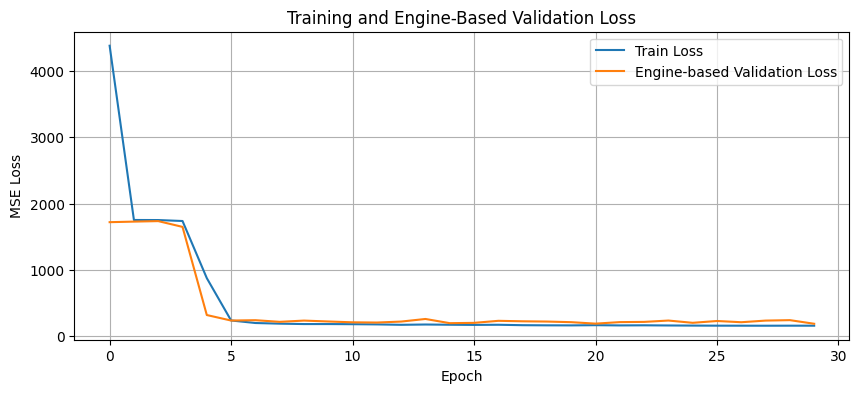

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Engine-based Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Engine-Based Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, y_pred, y_true = evaluate(model, test_loader, criterion, device)

y_pred = np.clip(y_pred, 0, None)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Test Loss (MSE):", test_loss)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

Test Loss (MSE): 206.5721276855469
Test RMSE: 14.37261730847581
Test MAE: 10.460478782653809
Test R2: 0.8803777098655701


In [20]:
def nasa_score(y_true, y_pred):
    errors = y_pred - y_true
    score = 0

    for e in errors:
        if e < 0:
            score += np.exp(-e / 13) - 1
        else:
            score += np.exp(e / 10) - 1

    return score


score = nasa_score(y_true, y_pred)
print("NASA score:", score)

NASA score: 304.31332


In [21]:
results_df = pd.DataFrame({
    "engine_id": np.arange(1, len(y_true) + 1),
    "true_rul": y_true,
    "predicted_rul": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true)
})

results_df.sort_values("abs_error", ascending=False).head(10)

,engine_id,true_rul,predicted_rul,error,abs_error
44,45,114.0,69.459526,-44.540474,44.540474
66,67,77.0,117.770027,40.770027,40.770027
24,25,145.0,108.078583,-36.921417,36.921417
92,93,85.0,50.388535,-34.611465,34.611465
95,96,137.0,107.542580,-29.457420,29.457420
73,74,126.0,98.659508,-27.340492,27.340492
46,47,135.0,108.192024,-26.807976,26.807976
78,79,63.0,89.693382,26.693382,26.693382
88,89,136.0,109.509308,-26.490692,26.490692
26,27,66.0,90.175468,24.175468,24.175468


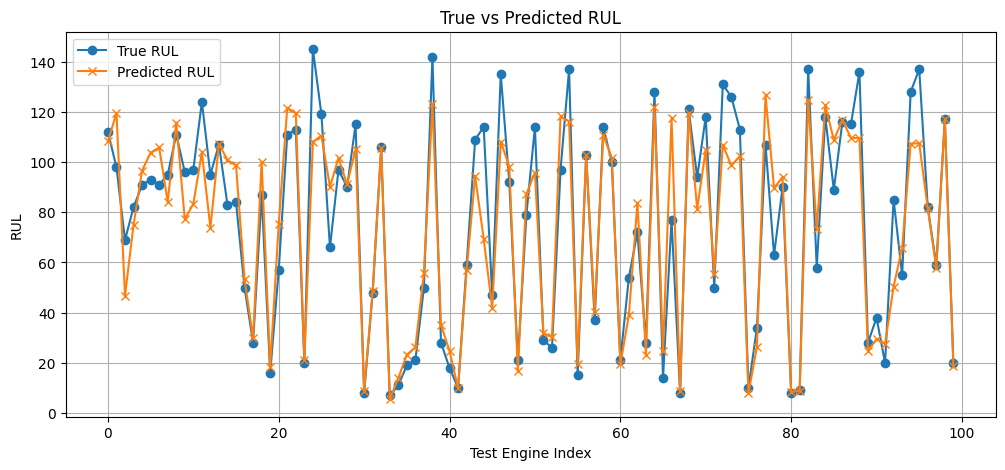

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="True RUL", marker="o")
plt.plot(y_pred, label="Predicted RUL", marker="x")
plt.xlabel("Test Engine Index")
plt.ylabel("RUL")
plt.title("True vs Predicted RUL")
plt.legend()
plt.grid(True)
plt.show()

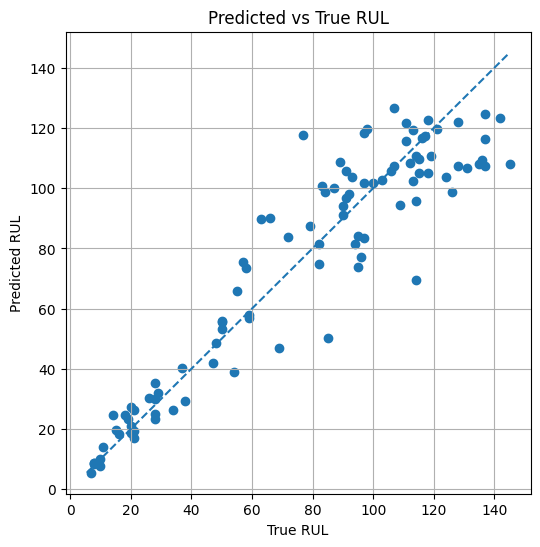

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred)

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL")
plt.grid(True)
plt.show()

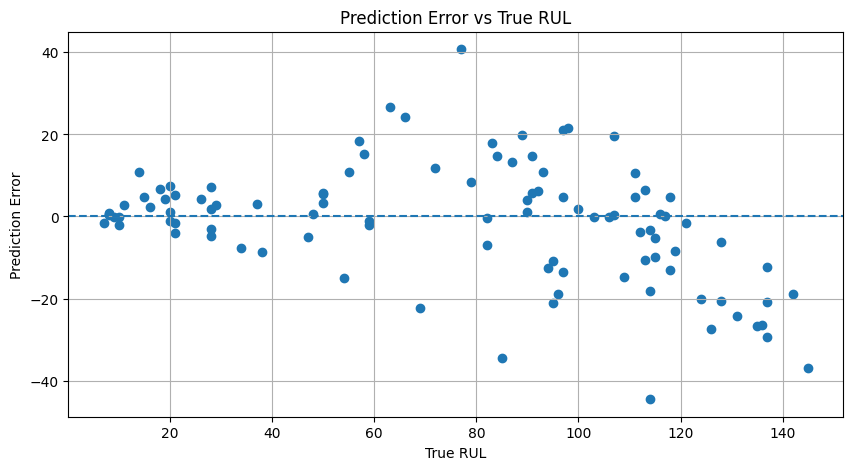

In [24]:
plt.figure(figsize=(10, 5))
plt.scatter(results_df["true_rul"], results_df["error"])
plt.axhline(0, linestyle="--")
plt.xlabel("True RUL")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs True RUL")
plt.grid(True)
plt.show()

In [25]:
results_path = RESULTS_DIR / f"{EXPERIMENT_NAME}_predictions.csv"
results_df.to_csv(results_path, index=False)

print("Predictions saved to:", results_path)

Predictions saved to: /home/flaviu/licenta/results/lstm_engine_val_seq30_cap125_predictions.csv


In [26]:
summary_path = RESULTS_DIR / "experiment_metrics_summary.csv"

new_row = pd.DataFrame([{
    "experiment": EXPERIMENT_NAME,
    "sequence_length": SEQ_LENGTH,
    "rul_cap": 125,
    "features": X_train.shape[2],
    "rmse": rmse,
    "mae": mae,
    "r2": r2,
    "nasa_score": score
}])

if summary_path.exists():
    old_df = pd.read_csv(summary_path)
    old_df = old_df[old_df["experiment"] != EXPERIMENT_NAME]
    summary_df = pd.concat([old_df, new_row], ignore_index=True)
else:
    summary_df = new_row

summary_df.to_csv(summary_path, index=False)
summary_df

,experiment,sequence_length,rul_cap,features,rmse,mae,r2,nasa_score
0,lstm_2layer_h128_dropout02_seq30_cap125,30,125,15,14.933655,10.971383,0.870856,407.173920
1,lstm_baseline_seq50_cap125,50,125,15,17.980077,12.138040,0.812792,891.001404
2,lstm_baseline_seq20_cap125,20,125,15,17.224204,12.465150,0.828202,732.156494
3,lstm_baseline_seq30_cap125,30,125,15,14.684165,11.080969,0.875135,335.621765
4,gru_engine_val_seq30_cap125,30,125,15,14.328155,10.473871,0.881117,325.169952
5,lstm_engine_val_seq30_cap125_asym_loss,30,125,15,15.758800,11.247834,0.856191,322.454010
6,lstm_engine_val_seq30_cap150_asym_loss,30,150,15,15.075860,10.877586,0.868385,409.623322
7,lstm_engine_val_seq30_cap150,30,150,15,17.366084,12.630200,0.825360,1178.916504
8,lstm_baseline_seq30_cap150,30,150,15,16.559425,12.318459,0.841207,796.785706
9,lstm_baseline_seq30_cap100,30,100,15,17.353853,12.807908,0.825606,388.370697
